# Task 3 – Multi-Stage Stochastic Programming Policy
**Decision Making under Uncertainty – Spring 2026 | Part B**

This notebook implements the complete SP policy:
1. System parameters (`get_fixed_data`)
2. Stochastic process models (price + occupancy)
3. Scenario generation
4. Pyomo MILP builder (constraints, overrule controllers, inertia)
5. Policy wrapper matching the `PolicyRestaurant2` template
6. Quick sanity-check / smoke test


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyomo.environ import (
    ConcreteModel, Set, Param, Var, Objective, Constraint, Block,
    SolverFactory, NonNegativeReals, minimize, Binary, value
)
from pyomo.opt import TerminationCondition


## 1. System Parameters

In [2]:
def get_fixed_data():
    """
    Returns the fixed system characteristics.
    THIS FUNCTION SHOULD NOT BE CHANGED.
    """
    num_timeslots = 10
    return {
        'num_timeslots'              : num_timeslots,
        'initial_temperature'        : 21.0,
        'previous_initial_temperature': 21.0,
        'initial_humidity'           : 40.0,
        'heating_max_power'          : 3.0,       # Pr  (kW)
        'heat_exchange_coeff'        : 0.6,        # ζ_exch
        'heating_efficiency_coeff'   : 1.0,        # ζ_conv
        'thermal_loss_coeff'         : 0.1,        # ζ_loss
        'heat_vent_coeff'            : 0.7,        # ζ_cool
        'heat_occupancy_coeff'       : 0.02,       # ζ_occ
        'temp_min_comfort_threshold' : 18.0,       # T_low
        'temp_OK_threshold'          : 22.0,       # T_OK
        'temp_max_comfort_threshold' : 26.0,       # T_high
        'humidity_threshold'         : 70.0,       # H_high
        'ventilation_power'          : 2.0,        # P_vent (kW)
        'humidity_occupancy_coeff'   : 0.18,       # η_occ
        'humidity_vent_coeff'        : 15.0,       # η_vent
        'outdoor_temperature'        : [
            3 * np.sin(2 * np.pi * t / num_timeslots - np.pi / 2)
            for t in range(num_timeslots)
        ],
    }

DATA = get_fixed_data()
print("System parameters loaded.")
print(f"  Horizon     : {DATA['num_timeslots']} hours")
print(f"  Max heating : {DATA['heating_max_power']} kW per room")
print(f"  T_low / T_OK / T_high : "
      f"{DATA['temp_min_comfort_threshold']} / "
      f"{DATA['temp_OK_threshold']} / "
      f"{DATA['temp_max_comfort_threshold']} °C")


System parameters loaded.
  Horizon     : 10 hours
  Max heating : 3.0 kW per room
  T_low / T_OK / T_high : 18.0 / 22.0 / 26.0 °C


## 2. Stochastic Process Models
From `PriceProcessRestaurant` and `OccupancyProcessRestaurant`.

In [3]:
# ── Electricity price process (AR(2)-like with mean reversion) ────────────────
def price_model(current_price, previous_price, rng=None):
    """
    One-step-ahead price sample.

    Parameters
    ----------
    current_price  : float  – price at t
    previous_price : float  – price at t-1
    rng            : numpy Generator (optional); uses np.random if None

    Returns
    -------
    float – sampled price at t+1
    """
    mean_price         = 4.0
    reversion_strength = 0.12
    price_cap          = 12.0
    price_floor        = 0.0

    mean_reversion = reversion_strength * (mean_price - current_price)
    noise          = (rng.normal(0, 0.5) if rng is not None
                      else np.random.normal(0, 0.5))

    next_price = (current_price
                  + 0.6 * (current_price - previous_price)
                  + mean_reversion
                  + noise)

    if next_price < 0:
        rand_val = rng.random() if rng is not None else np.random.rand()
        if rand_val > 0.2:
            next_price = (rng.uniform(0, mean_price * 0.3) if rng is not None
                          else np.random.uniform(0, mean_price * 0.3))

    return float(np.clip(next_price, price_floor, price_cap))


# ── Occupancy process (coupled mean-reverting, one room per step) ─────────────
def next_occupancy_levels(r1_current, r2_current, rng=None):
    """
    One-step-ahead occupancy sample for both rooms.

    Returns
    -------
    (r1_next, r2_next) : (float, float)
    """
    mean_r1, mean_r2 = 35.0, 25.0
    rev              = 0.25
    coupling         = 0.1

    noise_r1 = (rng.normal(0, 3.0) if rng is not None
                else np.random.normal(0, 3.0))
    noise_r2 = (rng.normal(0, 2.5) if rng is not None
                else np.random.normal(0, 2.5))

    r1_next = (r1_current
               + rev      * (mean_r1 - r1_current)
               + coupling * (r2_current - r1_current)
               + noise_r1)

    r2_next = (r2_current
               + rev      * (mean_r2 - r2_current)
               + coupling * (r1_current - r2_current)
               + noise_r2)

    return float(np.clip(r1_next, 20, 50)), float(np.clip(r2_next, 10, 30))


print("Process models defined: price_model(), next_occupancy_levels()")


Process models defined: price_model(), next_occupancy_levels()


## 3. Scenario Generation

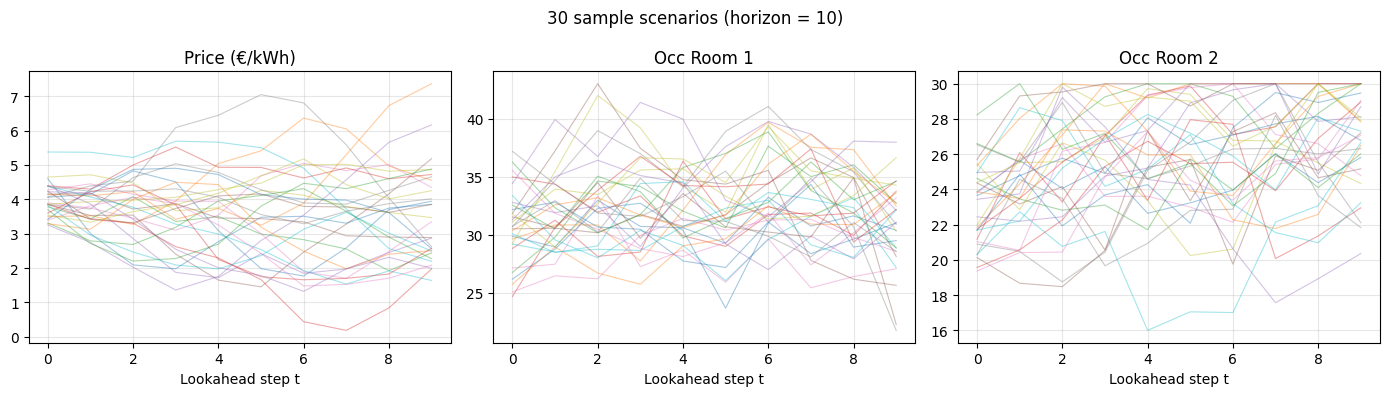

Scenario generation OK.


In [4]:
def generate_scenarios(price_now, price_prev,
                        occ_r1_now, occ_r2_now,
                        horizon, n_scenarios, rng):
    """
    Draw *n_scenarios* independent sample paths over *horizon* steps,
    starting from the current observed state.

    Returns
    -------
    price_dict   : {(t, s): float}        – price at lookahead step t, scenario s
    occ_dict     : {(r, t, s): float}     – occupancy of room r
    hum_occ_dict : {(t, s): float}        – total occupancy (both rooms)
    """
    price_dict   = {}
    occ_dict     = {}
    hum_occ_dict = {}

    for s in range(n_scenarios):
        p_cur,  p_prev  = price_now,   price_prev
        o1_cur, o2_cur  = occ_r1_now,  occ_r2_now

        for t in range(horizon):
            p_next          = price_model(p_cur, p_prev, rng)
            o1_next, o2_next = next_occupancy_levels(o1_cur, o2_cur, rng)

            price_dict[t, s]   = p_next
            occ_dict[1, t, s]  = o1_next
            occ_dict[2, t, s]  = o2_next
            hum_occ_dict[t, s] = o1_next + o2_next

            p_prev, p_cur   = p_cur,  p_next
            o1_cur, o2_cur  = o1_next, o2_next

    return price_dict, occ_dict, hum_occ_dict


# ── Quick visualisation of generated scenarios ────────────────────────────────
_rng_preview = np.random.default_rng(0)
_pd, _od, _ = generate_scenarios(
    price_now=4.0, price_prev=4.0,
    occ_r1_now=30.0, occ_r2_now=20.0,
    horizon=10, n_scenarios=30,
    rng=_rng_preview
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for s in range(30):
    axes[0].plot([_pd[t, s] for t in range(10)], alpha=0.4, lw=0.8)
    axes[1].plot([_od[1, t, s] for t in range(10)], alpha=0.4, lw=0.8)
    axes[2].plot([_od[2, t, s] for t in range(10)], alpha=0.4, lw=0.8)

for ax, title in zip(axes, ['Price (€/kWh)', 'Occ Room 1', 'Occ Room 2']):
    ax.set_xlabel('Lookahead step t')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

fig.suptitle('30 sample scenarios (horizon = 10)', fontsize=12)
plt.tight_layout()
plt.show()
print("Scenario generation OK.")


## 4. Stochastic MILP Builder

### Mathematical formulation summary

**Sets:**  $\mathcal{R}=\{1,2\}$, $\mathcal{T}=\{0,\dots,H-1\}$, $\mathcal{S}=\{0,\dots,S-1\}$

**Variables per $(r,t,s)$:** heating power $p_{r,t,s}$, binary indicators $u,w,y$, indoor temperature $T_{r,t,s}$  
**Variables per $(t,s)$:** ventilation $v_{t,s}\in\{0,1\}$, start/stop $u^\text{on}_{t,s},u^\text{off}_{t,s}$, humidity $H_{t,s}$

**Objective:** $\min \displaystyle\sum_s \pi_s \sum_t \lambda_{t,s}\!\left(\sum_r p_{r,t,s} + v_{t,s}\,P^\text{vent}\right)$

**Key constraint groups:**
- Temperature / humidity dynamics (linear)  
- Low-temp overrule: $u_{r,t,s}=1 \Rightarrow p_{r,t,s}=P^r_{\max}$, persists until $T\ge T^{\text{OK}}$  
- High-temp overrule: $y_{r,t,s}=1 \Rightarrow p_{r,t,s}=0$  
- Humidity overrule: $H_{t,s}>H^{\text{high}} \Rightarrow v_{t,s}=1$  
- Ventilation inertia: 3-hour minimum ON time  
- **Non-anticipativity** at $t=0$: all scenarios share the same here-and-now action


In [5]:
def build_sp_model(current_state, price_dict, occ_dict, hum_occ_dict,
                   horizon, n_scenarios):
    """
    Build the stochastic MILP for the SP policy.

    Parameters
    ----------
    current_state : dict with keys
        T_in_r1      – current temperature room 1  (°C)
        T_in_r2      – current temperature room 2  (°C)
        humidity     – current humidity             (%)
        vent_prev    – ventilation status at t-1    (0 or 1)
        vent_on_count– consecutive hours vent has been ON (for inertia)
    price_dict    : {(t,s): float}
    occ_dict      : {(r,t,s): float}
    hum_occ_dict  : {(t,s): float}
    horizon       : int
    n_scenarios   : int

    Returns
    -------
    Pyomo ConcreteModel (unsolved)
    """
    d  = DATA
    M  = 200.0          # big-M constant (larger than any realistic T or H range)

    T_init = {1: current_state['T_in_r1'], 2: current_state['T_in_r2']}
    H_init = current_state['humidity']
    v_prev = int(current_state['vent_prev'])
    v_on_h = int(current_state.get('vent_on_count', 0))

    m = ConcreteModel()

    # ── Sets ──────────────────────────────────────────────────────────────────
    m.R   = Set(initialize=[1, 2])
    m.T   = Set(initialize=list(range(horizon)))
    m.S   = Set(initialize=list(range(n_scenarios)))
    m.RTS = m.R * m.T * m.S
    m.TS  = m.T * m.S

    # ── Parameters ────────────────────────────────────────────────────────────
    m.Pr    = Param(initialize=d['heating_max_power'])
    m.Zexch = Param(initialize=d['heat_exchange_coeff'])
    m.Zconv = Param(initialize=d['heating_efficiency_coeff'])
    m.Zloss = Param(initialize=d['thermal_loss_coeff'])
    m.Zcool = Param(initialize=d['heat_vent_coeff'])
    m.Zocc  = Param(initialize=d['heat_occupancy_coeff'])
    m.Tmin  = Param(initialize=d['temp_min_comfort_threshold'])
    m.Tok   = Param(initialize=d['temp_OK_threshold'])
    m.Thigh = Param(initialize=d['temp_max_comfort_threshold'])
    m.Hhigh = Param(initialize=d['humidity_threshold'])
    m.Pvent = Param(initialize=d['ventilation_power'])
    m.Hocc  = Param(initialize=d['humidity_occupancy_coeff'])
    m.Hvent = Param(initialize=d['humidity_vent_coeff'])
    m.Tout  = Param(m.T, initialize={t: d['outdoor_temperature'][t]
                                      for t in range(horizon)})
    m.pi    = Param(m.S, initialize=1.0 / n_scenarios)

    m.O      = Param(m.RTS, initialize=occ_dict)
    m.prices = Param(m.TS,  initialize=price_dict)
    m.HumOcc = Param(m.TS,  initialize=hum_occ_dict)

    # ── Decision variables ────────────────────────────────────────────────────
    m.Heat = Var(m.RTS, domain=NonNegativeReals, bounds=(0, d['heating_max_power']))
    m.Vent = Var(m.TS,  domain=Binary)
    m.Uon  = Var(m.TS,  domain=Binary)   # ventilation start-up indicator
    m.Uoff = Var(m.TS,  domain=Binary)   # ventilation shut-down indicator

    # ── Auxiliary binary variables for overrule controllers ───────────────────
    m.u = Var(m.RTS, domain=Binary)   # 1 → low-temp overrule active
    m.w = Var(m.RTS, domain=Binary)   # 1 → temperature has recovered to T_OK
    m.y = Var(m.RTS, domain=Binary)   # 1 → high-temp overrule active

    # ── State variables ───────────────────────────────────────────────────────
    m.T_in = Var(m.RTS, domain=NonNegativeReals)
    m.Hum  = Var(m.TS,  domain=NonNegativeReals)

    # ── Temperature dynamics ──────────────────────────────────────────────────
    def temp_dynamics(m, r, t, s):
        if t == 0:
            return m.T_in[r, t, s] == T_init[r]
        tp = t - 1
        other_r = 2 if r == 1 else 1
        return m.T_in[r, t, s] == (
            m.T_in[r, tp, s]
            + m.Zexch * (m.T_in[other_r, tp, s] - m.T_in[r, tp, s])
            + m.Zloss * (m.Tout[tp]              - m.T_in[r, tp, s])
            + m.Zconv * m.Heat[r, tp, s]
            - m.Zcool * m.Vent[tp, s]
            + m.Zocc  * m.O[r, tp, s]
        )
    m.TempDyn = Constraint(m.RTS, rule=temp_dynamics)

    # ── Humidity dynamics ─────────────────────────────────────────────────────
    def hum_dynamics(m, t, s):
        if t == 0:
            return m.Hum[t, s] == H_init
        tp = t - 1
        return m.Hum[t, s] == (
            m.Hum[tp, s]
            - m.Hvent * m.Vent[tp, s]
            + m.Hocc  * m.HumOcc[tp, s]
        )
    m.HumDyn = Constraint(m.TS, rule=hum_dynamics)

    # ── Overrule controller: LOW temperature ──────────────────────────────────
    # u[r,t,s] = 1  iff  overrule is active (T < T_low or still recovering)
    # w[r,t,s] = 1  iff  T has reached T_OK this step (deactivates overrule)

    def u_activation(m, r, t, s):
        # T_in >= T_low - M*u  →  u forced to 1 when T < T_low
        return m.T_in[r, t, s] >= m.Tmin - M * m.u[r, t, s]
    m.UActivation = Constraint(m.RTS, rule=u_activation)

    def w_deactivation(m, r, t, s):
        # T_in >= T_OK - M*(1-w)  →  w forced to 1 when T >= T_OK
        return m.T_in[r, t, s] >= m.Tok - M * (1 - m.w[r, t, s])
    m.WDeactivation = Constraint(m.RTS, rule=w_deactivation)

    def u_persistence(m, r, t, s):
        # Overrule persists: u[t] >= u[t-1] - w[t]
        if t == 0:
            m.u[r, t, s].fix(0)
            m.w[r, t, s].fix(0)
            return Constraint.Skip
        return m.u[r, t, s] >= m.u[r, t - 1, s] - m.w[r, t, s]
    m.UPersistence = Constraint(m.RTS, rule=u_persistence)

    def heat_max_when_overrule(m, r, t, s):
        # u = 1  →  Heat = Pr
        return m.Heat[r, t, s] >= m.Pr * m.u[r, t, s]
    m.HeatMaxOverrule = Constraint(m.RTS, rule=heat_max_when_overrule)

    # ── Overrule controller: HIGH temperature ─────────────────────────────────
    def y_activation(m, r, t, s):
        # T_in <= T_high + M*y  →  y forced to 1 when T > T_high
        return m.T_in[r, t, s] <= m.Thigh + M * m.y[r, t, s]
    m.YActivation = Constraint(m.RTS, rule=y_activation)

    def heat_off_when_overrule(m, r, t, s):
        # y = 1  →  Heat = 0
        return m.Heat[r, t, s] <= m.Pr * (1 - m.y[r, t, s])
    m.HeatOffOverrule = Constraint(m.RTS, rule=heat_off_when_overrule)

    # ── Humidity overrule: force ventilation ON ───────────────────────────────
    def vent_humidity_overrule(m, t, s):
        # Hum <= H_high + M*v  →  v forced to 1 when Hum > H_high
        return m.Hum[t, s] <= m.Hhigh + M * m.Vent[t, s]
    m.VentHumOverrule = Constraint(m.TS, rule=vent_humidity_overrule)

    # ── Ventilation inertia: 3-hour minimum ON time ───────────────────────────
    def on_off_exclusivity(m, t, s):
        return m.Uon[t, s] + m.Uoff[t, s] <= 1
    m.OnOffExcl = Constraint(m.TS, rule=on_off_exclusivity)

    def uoff_bound(m, t, s):
        return m.Uoff[t, s] <= 1 - m.Vent[t, s]
    m.UoffBound = Constraint(m.TS, rule=uoff_bound)

    def uon_bound(m, t, s):
        return m.Uon[t, s] <= 1 - m.Vent[t, s]
    m.UonBound = Constraint(m.TS, rule=uon_bound)

    def min_uptime(m, t, s):
        L         = 3
        remaining = [k for k in range(t, t + L) if k <= m.T.last()]
        v_p       = v_prev if t == 0 else m.Vent[t - 1, s]
        return (sum(m.Vent[k, s] for k in remaining)
                >= len(remaining) * (m.Vent[t, s] - v_p))
    m.MinUptime = Constraint(m.TS, rule=min_uptime)

    # Carry over inertia commitment from previous real-system hours
    if v_prev == 1 and v_on_h < 3:
        forced_on = 3 - v_on_h
        for t in range(min(forced_on, horizon)):
            for s in range(n_scenarios):
                m.Vent[t, s].fix(1)

    # ── Non-anticipativity at t = 0 (here-and-now decisions) ─────────────────
    # All scenarios must agree on the first-stage action.
    def heat_na(m, r, s1, s2):
        if s1 >= s2:
            return Constraint.Skip
        return m.Heat[r, 0, s1] == m.Heat[r, 0, s2]
    m.HeatNA = Constraint(m.R, m.S, m.S, rule=heat_na)

    def vent_na(m, s1, s2):
        if s1 >= s2:
            return Constraint.Skip
        return m.Vent[0, s1] == m.Vent[0, s2]
    m.VentNA = Constraint(m.S, m.S, rule=vent_na)

    # ── Objective: minimise expected electricity cost ─────────────────────────
    def objective(m):
        return sum(
            m.pi[s] * sum(
                m.prices[t, s] * (
                    sum(m.Heat[r, t, s] for r in m.R)
                    + m.Vent[t, s] * m.Pvent
                )
                for t in m.T
            )
            for s in m.S
        )
    m.obj = Objective(rule=objective, sense=minimize)

    return m


print("build_sp_model() defined.")


build_sp_model() defined.


## 5. Policy Function (PolicyRestaurant2 template)

In [6]:
# ── Hyper-parameters ──────────────────────────────────────────────────────────
HORIZON     = 6    # lookahead steps (H)
N_SCENARIOS = 20   # number of sampled scenario trajectories (S)

# Reproducible RNG (re-seed once per Python session)
_rng = np.random.default_rng(seed=42)

# ─────────────────────────────────────────────────────────────────────────────
# DO NOT CHANGE the def line or the return line below.
# ─────────────────────────────────────────────────────────────────────────────
def SP_policy(
    t,               # current hour index (0-based, 0..9)
    T_in,            # list [T_room1 (°C), T_room2 (°C)]
    humidity,        # current humidity level (%)
    vent_status,     # ventilation ON/OFF at t-1  (0 or 1)
    vent_on_count,   # consecutive hours ventilation has been ON
    price_now,       # electricity price at current hour
    price_prev,      # electricity price at previous hour (or None at t=0)
    occ_r1,          # occupancy room 1 at current hour
    occ_r2,          # occupancy room 2 at current hour
):
    """
    Multi-stage stochastic programming policy.

    Design choices
    --------------
    Lookahead horizon  : H = 6 steps
    Scenarios          : S = 20 independent sample paths (equal weight 1/S)
    Tree structure     : single-branch (all scenarios diverge from t=0)
    Non-anticipativity : enforced only at t=0 (here-and-now)
    Solver             : Gurobi, TimeLimit=12s, MIPGap=2%

    Returns
    -------
    heat_r1 : float – heating power room 1 (kW)
    heat_r2 : float – heating power room 2 (kW)
    vent    : int   – ventilation decision  (0 or 1)
    """
    # How many lookahead steps remain today
    remaining = DATA['num_timeslots'] - t
    horizon   = min(HORIZON, remaining)

    if horizon <= 0:
        return 0.0, 0.0, 0

    # Handle missing previous price at t=0
    if price_prev is None:
        price_prev = price_now

    # ── Generate S scenarios from current state ───────────────────────────────
    price_dict, occ_dict, hum_occ_dict = generate_scenarios(
        price_now   = price_now,
        price_prev  = price_prev,
        occ_r1_now  = occ_r1,
        occ_r2_now  = occ_r2,
        horizon     = horizon,
        n_scenarios = N_SCENARIOS,
        rng         = _rng,
    )

    current_state = {
        'T_in_r1'      : T_in[0],
        'T_in_r2'      : T_in[1],
        'humidity'     : humidity,
        'vent_prev'    : int(vent_status),
        'vent_on_count': int(vent_on_count),
    }

    # ── Build and solve the stochastic MILP ───────────────────────────────────
    model  = build_sp_model(current_state, price_dict, occ_dict, hum_occ_dict,
                             horizon, N_SCENARIOS)
    solver = SolverFactory('gurobi')
    solver.options['TimeLimit'] = 12    # wall-clock limit (s) – stay under 15s
    solver.options['MIPGap']    = 0.02  # 2% optimality gap is acceptable
    result = solver.solve(model, tee=False)

    # ── Extract here-and-now decisions (all scenarios agree at t=0) ───────────
    s0  = 0    # any scenario works due to non-anticipativity
    p1  = float(value(model.Heat[1, 0, s0]))
    p2  = float(value(model.Heat[2, 0, s0]))
    v   = int(round(float(value(model.Vent[0, s0]))))

    # Safety clip to feasible bounds
    pr_max = DATA['heating_max_power']
    p1 = float(np.clip(p1, 0.0, pr_max))
    p2 = float(np.clip(p2, 0.0, pr_max))
    v  = int(np.clip(v,  0,   1))

    return p1, p2, v   # DO NOT CHANGE this line


print("SP_policy() defined.")
print(f"  Horizon      = {HORIZON} steps")
print(f"  Scenarios    = {N_SCENARIOS}")


SP_policy() defined.
  Horizon      = 6 steps
  Scenarios    = 20


## 6. Smoke Test
Run the policy for a single hour to verify it solves correctly and returns valid outputs.

In [7]:
# ── Test inputs: hour 0, typical starting conditions ─────────────────────────
test_t           = 0
test_T_in        = [21.0, 21.0]
test_humidity    = 40.0
test_vent_status = 0
test_vent_on_count = 0
test_price_now   = 4.5
test_price_prev  = None          # no previous price at t=0
test_occ_r1      = 30.0
test_occ_r2      = 20.0

print("Running SP_policy() for hour t=0 …")
heat_r1, heat_r2, vent = SP_policy(
    t             = test_t,
    T_in          = test_T_in,
    humidity      = test_humidity,
    vent_status   = test_vent_status,
    vent_on_count = test_vent_on_count,
    price_now     = test_price_now,
    price_prev    = test_price_prev,
    occ_r1        = test_occ_r1,
    occ_r2        = test_occ_r2,
)

print(f"\nResults for hour t={test_t}:")
print(f"  Heating Room 1 : {heat_r1:.4f} kW  (bounds [0, {DATA['heating_max_power']}])")
print(f"  Heating Room 2 : {heat_r2:.4f} kW  (bounds [0, {DATA['heating_max_power']}])")
print(f"  Ventilation    : {vent}            (0=OFF, 1=ON)")

pr_max = DATA['heating_max_power']
assert 0.0 - 1e-6 <= heat_r1 <= pr_max + 1e-6, f"heat_r1 out of bounds: {heat_r1}"
assert 0.0 - 1e-6 <= heat_r2 <= pr_max + 1e-6, f"heat_r2 out of bounds: {heat_r2}"
assert vent in (0, 1),                           f"vent not binary: {vent}"
print("\nAll bound checks passed ✓")


Running SP_policy() for hour t=0 …

Results for hour t=0:
  Heating Room 1 : 0.0000 kW  (bounds [0, 3.0])
  Heating Room 2 : 0.0000 kW  (bounds [0, 3.0])
  Ventilation    : 0            (0=OFF, 1=ON)

All bound checks passed ✓


## 7. Full-Day Simulation
Run the policy over an entire 10-hour day, propagating the real system state between hours.
This is equivalent to the simulation loop in `Task 6` and validates end-to-end behaviour.


In [8]:
def simulate_one_day(price_series, occ_r1_series, occ_r2_series, verbose=True):
    """
    Simulate a single day with the SP_policy.

    Parameters
    ----------
    price_series   : list of 10 floats – electricity price at each hour
    occ_r1_series  : list of 10 floats – room-1 occupancy at each hour
    occ_r2_series  : list of 10 floats – room-2 occupancy at each hour

    Returns
    -------
    dict of result arrays (temperatures, heat, vent, humidity, cost)
    """
    d = DATA
    T   = d['num_timeslots']
    M   = 200.0

    # ── Real system state ─────────────────────────────────────────────────────
    T_in        = [d['initial_temperature'], d['initial_temperature']]
    humidity    = d['initial_humidity']
    vent_prev   = 0
    vent_on_cnt = 0
    price_prev  = None

    # ── Logs ──────────────────────────────────────────────────────────────────
    log = {k: [] for k in
           ['t','T1','T2','H','p1','p2','v','price','cost_t']}

    total_cost = 0.0

    for t in range(T):
        p_now  = price_series[t]
        o1_now = occ_r1_series[t]
        o2_now = occ_r2_series[t]

        # ── Query policy ──────────────────────────────────────────────────────
        p1, p2, v = SP_policy(
            t=t, T_in=T_in, humidity=humidity,
            vent_status=vent_prev, vent_on_count=vent_on_cnt,
            price_now=p_now, price_prev=price_prev,
            occ_r1=o1_now, occ_r2=o2_now,
        )

        # ── Apply overrule controllers to REAL system ─────────────────────────
        # Low-temp overrule
        for r_idx, Ti in enumerate(T_in):
            if Ti < d['temp_min_comfort_threshold']:
                if r_idx == 0: p1 = d['heating_max_power']
                else:          p2 = d['heating_max_power']
        # High-temp overrule
        for r_idx, Ti in enumerate(T_in):
            if Ti > d['temp_max_comfort_threshold']:
                if r_idx == 0: p1 = 0.0
                else:          p2 = 0.0
        # Humidity overrule
        if humidity > d['humidity_threshold']:
            v = 1
        # Inertia: ventilation must stay ON if it was just started
        if vent_prev == 1 and vent_on_cnt < 3:
            v = 1

        # ── Compute cost at this hour ─────────────────────────────────────────
        cost_t  = p_now * (p1 + p2 + v * d['ventilation_power'])
        total_cost += cost_t

        # ── Log ───────────────────────────────────────────────────────────────
        for key, val in zip(['t','T1','T2','H','p1','p2','v','price','cost_t'],
                             [t, T_in[0], T_in[1], humidity, p1, p2, v, p_now, cost_t]):
            log[key].append(val)

        if verbose:
            print(f"  t={t:2d} | T=({T_in[0]:5.2f},{T_in[1]:5.2f}) | "
                  f"H={humidity:5.1f}% | p=({p1:.2f},{p2:.2f}) | "
                  f"v={v} | price={p_now:.2f} | cost={cost_t:.2f}")

        # ── Advance real system state (using decisions just made) ─────────────
        T1_new = (T_in[0]
                  + d['heat_exchange_coeff'] * (T_in[1] - T_in[0])
                  + d['thermal_loss_coeff']  * (d['outdoor_temperature'][t] - T_in[0])
                  + d['heating_efficiency_coeff'] * p1
                  - d['heat_vent_coeff'] * v
                  + d['heat_occupancy_coeff'] * o1_now)

        T2_new = (T_in[1]
                  + d['heat_exchange_coeff'] * (T_in[0] - T_in[1])
                  + d['thermal_loss_coeff']  * (d['outdoor_temperature'][t] - T_in[1])
                  + d['heating_efficiency_coeff'] * p2
                  - d['heat_vent_coeff'] * v
                  + d['heat_occupancy_coeff'] * o2_now)

        humidity = (humidity
                    - d['humidity_vent_coeff']      * v
                    + d['humidity_occupancy_coeff'] * (o1_now + o2_now))
        humidity = max(humidity, 0.0)

        T_in    = [T1_new, T2_new]
        if v == 1 and vent_prev == 0:
            vent_on_cnt = 1
        elif v == 1:
            vent_on_cnt = min(vent_on_cnt + 1, 3)
        else:
            vent_on_cnt = 0
        vent_prev  = v
        price_prev = p_now

    if verbose:
        print(f"\n  Total daily cost: {total_cost:.4f} EUR")
    log['total_cost'] = total_cost
    return log


# ── Run on a sample day ───────────────────────────────────────────────────────
np.random.seed(7)
sample_prices = [float(np.clip(np.random.normal(4, 1), 0, 12)) for _ in range(10)]
sample_occ_r1 = [float(np.clip(np.random.normal(30, 5), 20, 50)) for _ in range(10)]
sample_occ_r2 = [float(np.clip(np.random.normal(20, 4), 10, 30)) for _ in range(10)]

print("Simulating one day …\n")
log = simulate_one_day(sample_prices, sample_occ_r1, sample_occ_r2, verbose=True)


Simulating one day …

  t= 0 | T=(21.00,21.00) | H= 40.0% | p=(0.00,0.00) | v=0 | price=5.69 | cost=0.00
  t= 1 | T=(19.14,19.13) | H= 49.6% | p=(0.64,0.74) | v=0 | price=3.53 | cost=4.90
  t= 2 | T=(18.21,18.13) | H= 58.6% | p=(1.45,1.63) | v=0 | price=4.03 | cost=12.42
  t= 3 | T=(18.35,18.27) | H= 67.8% | p=(2.03,2.08) | v=1 | price=4.41 | cost=26.91
  t= 4 | T=(18.46,18.52) | H= 63.0% | p=(1.93,2.01) | v=1 | price=3.21 | cost=19.07
  t= 5 | T=(18.70,18.58) | H= 56.7% | p=(1.84,1.93) | v=1 | price=4.00 | cost=23.09
  t= 6 | T=(18.65,18.61) | H= 48.4% | p=(1.00,1.19) | v=0 | price=4.00 | cost=8.76
  t= 7 | T=(18.66,18.58) | H= 57.6% | p=(1.04,1.32) | v=0 | price=2.25 | cost=5.30
  t= 8 | T=(18.49,18.39) | H= 65.1% | p=(1.21,1.30) | v=0 | price=5.02 | cost=12.58
  t= 9 | T=(18.33,18.30) | H= 75.1% | p=(0.00,0.00) | v=1 | price=4.60 | cost=9.20

  Total daily cost: 122.2298 EUR


## 8. Result Visualisation

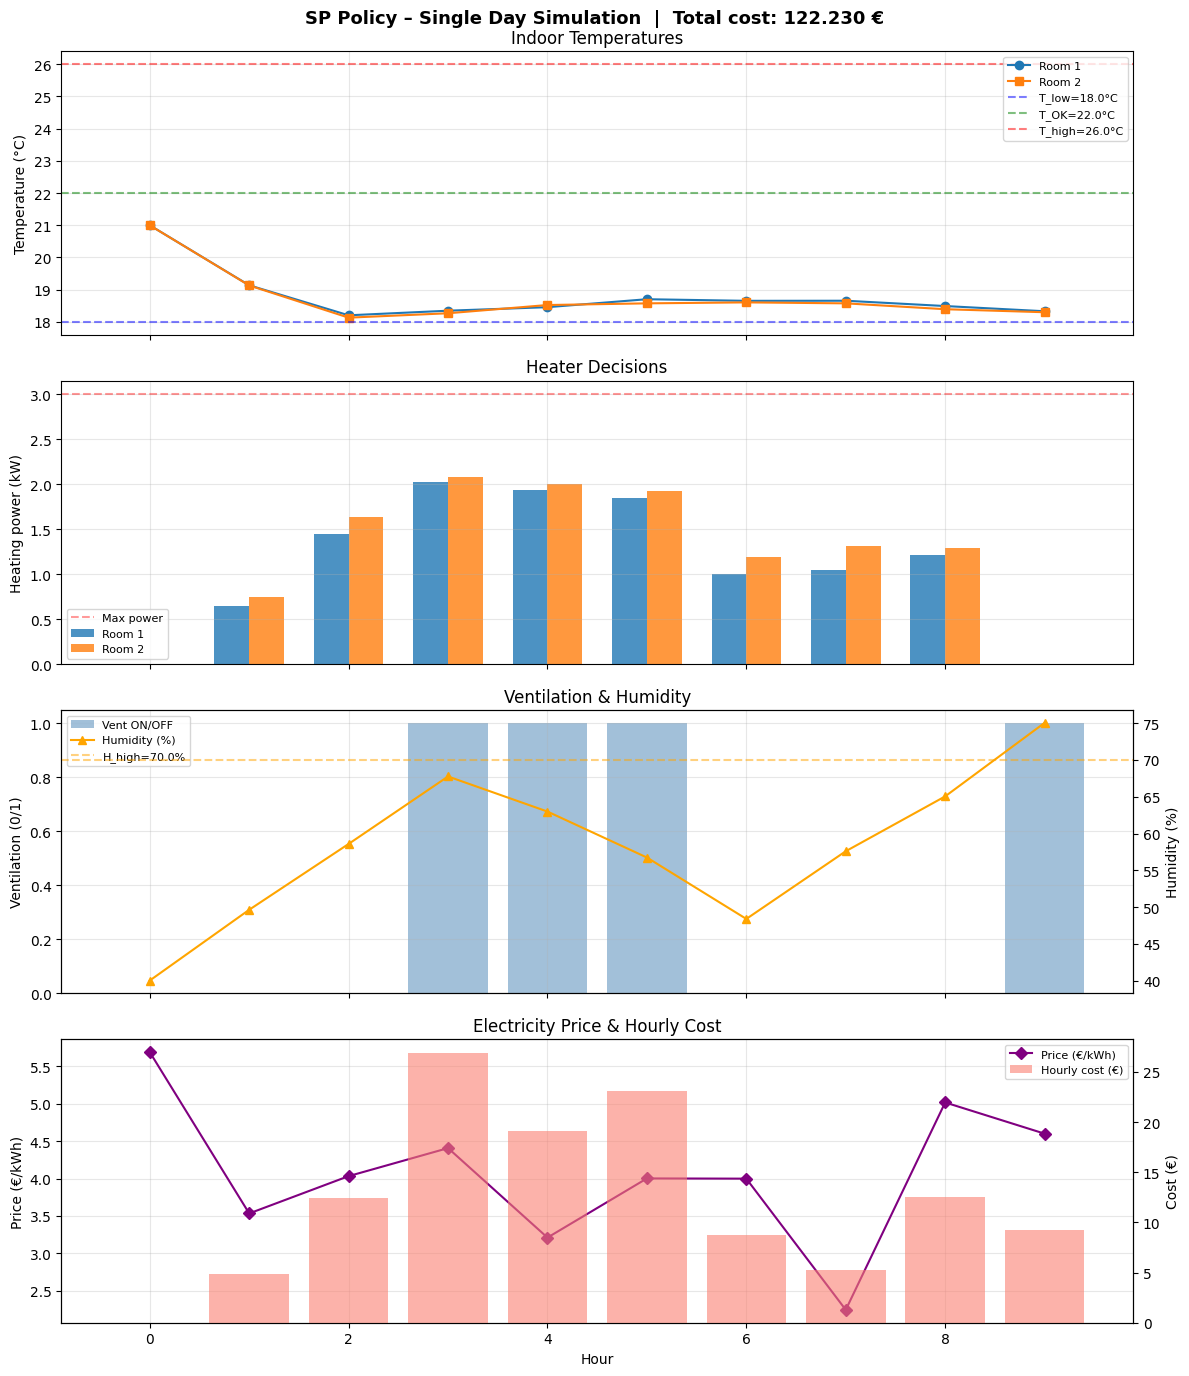

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
T_range = log['t']

# Temperatures
axes[0].plot(T_range, log['T1'], marker='o', label='Room 1')
axes[0].plot(T_range, log['T2'], marker='s', label='Room 2')
axes[0].axhline(DATA['temp_min_comfort_threshold'], ls='--', color='blue',  alpha=0.5, label=f"T_low={DATA['temp_min_comfort_threshold']}°C")
axes[0].axhline(DATA['temp_OK_threshold'],          ls='--', color='green', alpha=0.5, label=f"T_OK={DATA['temp_OK_threshold']}°C")
axes[0].axhline(DATA['temp_max_comfort_threshold'], ls='--', color='red',   alpha=0.5, label=f"T_high={DATA['temp_max_comfort_threshold']}°C")
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Indoor Temperatures')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Heating power
w = 0.35
axes[1].bar([x - w/2 for x in T_range], log['p1'], width=w, label='Room 1', alpha=0.8)
axes[1].bar([x + w/2 for x in T_range], log['p2'], width=w, label='Room 2', alpha=0.8)
axes[1].axhline(DATA['heating_max_power'], ls='--', color='red', alpha=0.4, label='Max power')
axes[1].set_ylabel('Heating power (kW)')
axes[1].set_title('Heater Decisions')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Ventilation + humidity
ax_v = axes[2]
ax_h = ax_v.twinx()
ax_v.bar(T_range, log['v'], color='steelblue', alpha=0.5, label='Vent ON/OFF')
ax_h.plot(T_range, log['H'], marker='^', color='orange', label='Humidity (%)')
ax_h.axhline(DATA['humidity_threshold'], ls='--', color='orange', alpha=0.5,
             label=f"H_high={DATA['humidity_threshold']}%")
ax_v.set_ylabel('Ventilation (0/1)')
ax_h.set_ylabel('Humidity (%)')
axes[2].set_title('Ventilation & Humidity')
lines1, labs1 = ax_v.get_legend_handles_labels()
lines2, labs2 = ax_h.get_legend_handles_labels()
ax_v.legend(lines1 + lines2, labs1 + labs2, fontsize=8)
axes[2].grid(True, alpha=0.3)

# Electricity price + cost
ax_p = axes[3]
ax_c = ax_p.twinx()
ax_p.plot(T_range, log['price'], marker='D', color='purple', label='Price (€/kWh)')
ax_c.bar(T_range, log['cost_t'], color='salmon', alpha=0.6, label='Hourly cost (€)')
ax_p.set_ylabel('Price (€/kWh)')
ax_c.set_ylabel('Cost (€)')
axes[3].set_title('Electricity Price & Hourly Cost')
axes[3].set_xlabel('Hour')
lines1, labs1 = ax_p.get_legend_handles_labels()
lines2, labs2 = ax_c.get_legend_handles_labels()
ax_p.legend(lines1 + lines2, labs1 + labs2, fontsize=8)
axes[3].grid(True, alpha=0.3)

fig.suptitle(f"SP Policy – Single Day Simulation  |  Total cost: {log['total_cost']:.3f} €",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
